 Netflix EDA — Content & User Analysis

___Objective___:Explore Netflix's content catalogue and user behaviour to uncover trends, audience segments, and content gaps.

Datasets
- `netflix_titles.csv` — ~8,800 titles with metadata (type, country, genre, release year, rating)
- `netflix_users.csv` — ~25,000 users with watch behaviour (hours, subscription, favorite genre, age)

sections:
1. Data Loading & Cleaning
2. Content Analysis (Movies vs Shows, Growth, Countries, Genres)
3. User Analysis (Watch Time, Subscriptions, Favorite Genres)
4. Audience Segmentation
5. Age Analysis
6. Content Gap Analysis
7. Correlation Heatmap
8. Recommendation System
9. Conclusion

In [12]:
from google.colab import files
uploaded = files.upload()

Saving netflix_titles.csv to netflix_titles (1).csv
Saving netflix_users.csv to netflix_users (1).csv


In [49]:
!pip install -U kaleido

In [50]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "colab"


In [51]:
title = pd.read_csv("netflix_titles.csv")
users = pd.read_csv("netflix_users.csv")

In [52]:
title.shape

(8807, 12)

In [53]:
users.shape

(25000, 8)

In [54]:
title.info

<bound method DataFrame.info of      show_id     type                  title         director  \
0         s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV Show          Blood & Water              NaN   
2         s3  TV Show              Ganglands  Julien Leclercq   
3         s4  TV Show  Jailbirds New Orleans              NaN   
4         s5  TV Show           Kota Factory              NaN   
...      ...      ...                    ...              ...   
8802   s8803    Movie                 Zodiac    David Fincher   
8803   s8804  TV Show            Zombie Dumb              NaN   
8804   s8805    Movie             Zombieland  Ruben Fleischer   
8805   s8806    Movie                   Zoom     Peter Hewitt   
8806   s8807    Movie                 Zubaan      Mozez Singh   

                                                   cast        country  \
0                                                   NaN  United States   
1     Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2     Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                   NaN            NaN   
4     Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   
...                                                 ...            ...   
8802  Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...  United States   
8803                                                NaN            NaN   
8804  Jesse Eisenberg, Woody Harrelson, Emma Stone, ...  United States   
8805  Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...  United States   
8806  Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...          India   

              date_added  release_year rating   duration  \
0     September 25, 2021          2020  PG-13     90 min   
1     September 24, 2021          2021  TV-MA  2 Seasons   
2     September 24, 2021          2021  TV-MA   1 Season   
3     September 24, 2021          2021  TV-MA   1 Season   
4     September 24, 2021          2021  TV-MA  2 Seasons   
...                  ...           ...    ...        ...   
8802   November 20, 2019          2007      R    158 min   
8803        July 1, 2019          2018  TV-Y7  2 Seasons   
8804    November 1, 2019          2009      R     88 min   
8805    January 11, 2020          2006     PG     88 min   
8806       March 2, 2019          2015  TV-14    111 min   

                                              listed_in  \
0                                         Documentaries   
1       International TV Shows, TV Dramas, TV Mysteries   
2     Crime TV Shows, International TV Shows, TV Act...   
3                                Docuseries, Reality TV   
4     International TV Shows, Romantic TV Shows, TV ...   
...                                                 ...   
8802                     Cult Movies, Dramas, Thrillers   
8803             Kids' TV, Korean TV Shows, TV Comedies   
8804                            Comedies, Horror Movies   
8805                 Children & Family Movies, Comedies   
8806     Dramas, International Movies, Music & Musicals   

                                            description  
0     As her father nears the end of his life, filmm...  
1     After crossing paths at a party, a Cape Town t...  
2     To protect his family from a powerful drug lor...  
3     Feuds, flirtations and toilet talk go down amo...  
4     In a city of coaching centers known to train I...  
...                                                 ...  
8802  A political cartoonist, a crime reporter and a...  
8803  While living alone in a spooky town, a young g...  
8804  Looking to survive in a world taken over by zo...  
8805  Dragged from civilian life, a former superhero...  
8806  A scrappy but poor boy worms his way into a ty...  

[8807 rows x 12 columns]>

In [55]:
users.info

<bound method DataFrame.info of        User_ID              Name  Age    Country Subscription_Type  \
0            1    James Martinez   18     France           Premium   
1            2       John Miller   23        USA           Premium   
2            3        Emma Davis   60         UK             Basic   
3            4       Emma Miller   44        USA           Premium   
4            5        Jane Smith   68        USA          Standard   
...        ...               ...  ...        ...               ...   
24995    24996      David Miller   18  Australia           Premium   
24996    24997       Jane Miller   17        USA           Premium   
24997    24998      Sarah Miller   14        USA           Premium   
24998    24999  Michael Williams   71        USA             Basic   
24999    25000       James Jones   19    Germany           Premium   

       Watch_Time_Hours Favorite_Genre  Last_Login  
0                 80.26          Drama  2024-05-12  
1                321.75         Sci-Fi  2025-02-05  
2                 35.89         Comedy  2025-01-24  
3                261.56    Documentary  2024-03-25  
4                909.30          Drama  2025-01-14  
...                 ...            ...         ...  
24995            183.88         Horror  2025-01-18  
24996            112.37          Drama  2024-06-29  
24997            351.80         Action  2024-10-16  
24998            655.89         Action  2024-08-27  
24999            207.06    Documentary  2024-04-12  

[25000 rows x 8 columns]>

In [56]:
title.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [57]:
users.head()

,User_ID,Name,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Last_Login
0,1,James Martinez,18,France,Premium,80.26,Drama,2024-05-12
1,2,John Miller,23,USA,Premium,321.75,Sci-Fi,2025-02-05
2,3,Emma Davis,60,UK,Basic,35.89,Comedy,2025-01-24
3,4,Emma Miller,44,USA,Premium,261.56,Documentary,2024-03-25
4,5,Jane Smith,68,USA,Standard,909.30,Drama,2025-01-14


In [58]:
title.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [59]:
title["director"] = title["director"].fillna("Unknown")

In [60]:
title["country"] = title["country"].fillna("Unknown")

In [61]:
title["cast"] = title["cast"].fillna("Unknown")

In [62]:
title = title.dropna(subset=["date_added","rating","duration"])

In [63]:
users.isnull().sum()

,0
User_ID,0
Name,0
Age,0
Country,0
Subscription_Type,0
Watch_Time_Hours,0
Favorite_Genre,0
Last_Login,0


Movies vs TV Shows

In [64]:

content_type = title['type'].value_counts()


In [65]:
fig = px.bar(x = content_type.index,y = content_type.values,title="MOVIES VS SHOWS")
fig.show()

Netflix Growth

In [66]:
title.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [67]:
growth = title.groupby("release_year").size().reset_index(name="count")

In [68]:
fig = px.bar(growth,x = "release_year",y = "count",title ="Netflix content growth")
fig.show()

Top Countries

In [69]:
top_countries = title["country"].value_counts().head(20)


In [70]:
fig = px.bar(top_countries.reset_index(),x ="country",y = "count",title="Top Countries Producing Content" )
fig.show()

Genre Analysis

In [71]:
genre = (title["listed_in"].str.split(",").explode())

In [72]:
top_genre = genre.value_counts().head(20)

In [73]:
fig = px.bar(top_genre.reset_index(),x ="listed_in",y = "count",title="Top Netflix Genres")
fig.show()

                            USER ANALYSIS  

Favorite Genres

In [74]:
favorite_genre = users["Favorite_Genre"].value_counts()

In [75]:
fig = px.bar(favorite_genre.reset_index(),x = "Favorite_Genre",y = "count",title="Favorite Genres of Users")
fig.show()

Watch Time Distribution

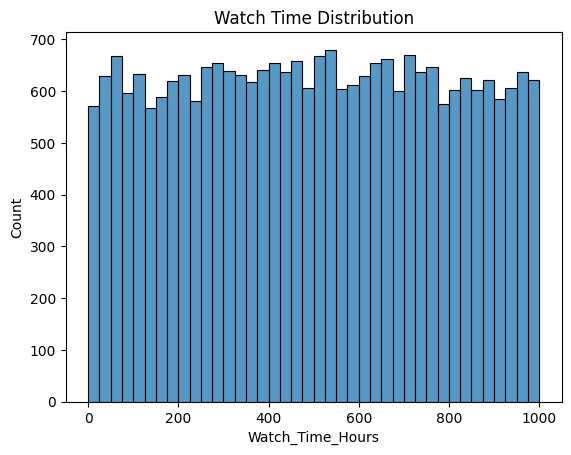

In [76]:
sns.histplot(users["Watch_Time_Hours"],bins=40)
plt.title("Watch Time Distribution")
plt.show()

Subscription Type

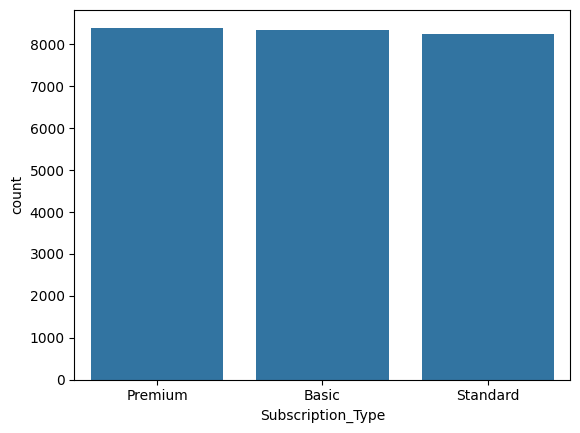

In [77]:

users["Subscription_Type"].value_counts()
sns.countplot(x="Subscription_Type",data = users)
plt.show()

                         AUDIENCE SEGMENTATION

In [78]:
def audiencetype(hours):
    if hours <20:
        return "Casual"
    elif hours <50:
        return "Regular"
    else:
        return "Binge"

In [79]:
users["user_type"] = (users["Watch_Time_Hours"].apply(audiencetype))
users["user_type"]

,user_type
0,Binge
1,Binge
2,Regular
3,Binge
4,Binge
...,...
24995,Binge
24996,Binge
24997,Binge
24998,Binge


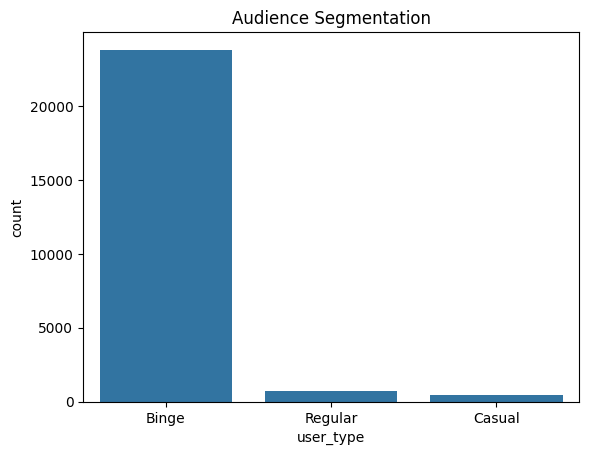

In [80]:
sns.countplot(
    x="user_type",
    data=users
)

plt.title(
    "Audience Segmentation"
)

plt.show()

                             AGE ANALYSIS

In [81]:
def age_group(age):
    if age<=18:
        return "Teen"
    elif age<= 30:
        return "Young adult"
    elif age<=50:
        return "adult"
    else:
        return "Senior"

In [82]:
users.head()

,User_ID,Name,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Last_Login,user_type
0,1,James Martinez,18,France,Premium,80.26,Drama,2024-05-12,Binge
1,2,John Miller,23,USA,Premium,321.75,Sci-Fi,2025-02-05,Binge
2,3,Emma Davis,60,UK,Basic,35.89,Comedy,2025-01-24,Regular
3,4,Emma Miller,44,USA,Premium,261.56,Documentary,2024-03-25,Binge
4,5,Jane Smith,68,USA,Standard,909.30,Drama,2025-01-14,Binge


In [83]:
users["Age_group"] = (users["Age"].apply(age_group))

In [84]:
age_watch = users.groupby("Age_group")["Watch_Time_Hours"].mean()

In [85]:
fig = px.bar(age_watch.reset_index(),x ="Age_group",y ="Watch_Time_Hours",title="Average Watch Time by Age Group")
fig.show()

                        CONTENT GAP ANALYSIS

In [86]:
genre_map = {
    "Drama": "Dramas",
    "Comedy": "Comedies",
    "Action": "Action & Adventure",
    "Horror": "Horror Movies",
    "Romance": "Romantic Movies",
    "Documentary": "Documentaries",
    "Sci-Fi": "Sci-Fi & Fantasy"
}

In [87]:
content_supply = (genre.value_counts().reset_index())

In [88]:
content_supply.columns = ["Genre","supply"]


In [89]:
audience_demand = (users["Favorite_Genre"].value_counts().reset_index())
audience_demand.columns = ["Genre","demand"]
audience_demand["Netflix_Genre"] = (
    audience_demand["Genre"]
    .map(genre_map)
)

In [90]:
gap = pd.merge(
    audience_demand,
    content_supply,
    left_on="Netflix_Genre",
    right_on="Genre",
    how="inner"
)
gap["Demand_supply_ratio"] = (gap["demand"]/gap["supply"])


In [91]:
gap = gap.sort_values("Demand_supply_ratio",ascending=False)

In [92]:
fig = px.bar(
    gap,
    x="Netflix_Genre",
    y="Demand_supply_ratio",
    title="Genres Netflix Should Invest More In"
)

fig.show()

                                      HEATMAP

In [93]:
corr = users.select_dtypes(include=np.number).corr()

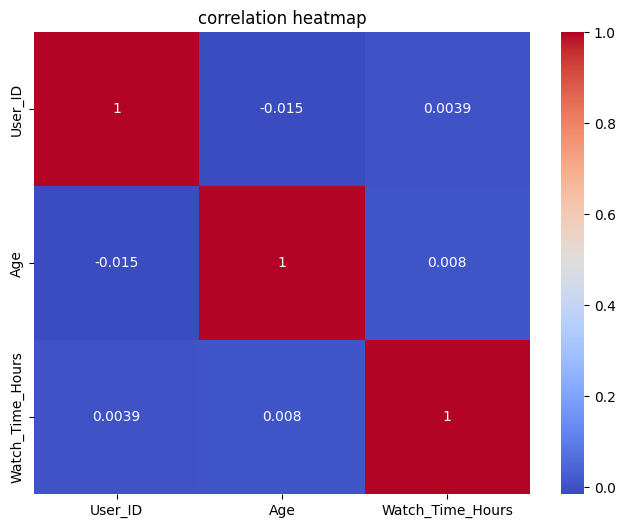

In [94]:
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("correlation heatmap")
plt.show()

                                RECOMMENDATION SYSTEM

In [95]:
def recommend(country, genre, n=10):
    result = title[
        (title["country"].str.contains(country, case=False, na=False)) &
        (title["listed_in"].str.contains(genre, case=False, na=False))
    ]
    return result[["title", "type", "release_year", "rating"]].head(n)

recommend("India", "Drama")

,title,type,release_year,rating
50,Dharmakshetra,TV Show,2014,TV-PG
69,Stories by Rabindranath Tagore,TV Show,2015,TV-PG
105,Angamaly Diaries,Movie,2017,TV-14
114,Anjaam,Movie,1994,TV-14
116,Dhanak,Movie,2015,TV-PG
118,Gurgaon,Movie,2017,TV-14
126,Shikara,Movie,2020,TV-14
190,Thimmarusu,Movie,2021,TV-14
195,EMI: Liya Hai To Chukana Padega,Movie,2008,TV-14
199,Koi Aap Sa,Movie,2006,TV-14


Conclusion

Key Findings

| # | Finding |
|---|---------|
| 1 | Netflix's catalogue is **70% Movies**, but TV Show production is growing faster |
| 2 | Content volume **peaked in 2018** and has declined — quality over quantity shift |
| 3 | **USA, India, UK** are the top 3 producing nations; K-Drama is a rising force |
| 4 | **International Movies and Dramas** dominate supply |
| 5 | **Sci-Fi (14.2x) and Horror (10.2x)** have the largest demand-supply gap — biggest opportunity |
| 6 | Subscription types are evenly distributed; watch time is uniformly spread across age groups |

Limitations
- `netflix_users.csv` appears to be **synthetically generated** — uniform distributions across watch time, age, and genres are unrealistic. Findings from user analysis should be interpreted with this in mind.
- Country field in `netflix_titles.csv` contains multi-country entries — a more rigorous analysis would explode and deduplicate these.
